# Quadratic Equation Solver — Conditional Workflow

**Graph:** START → show_equation → calculate_discriminant → [real_roots | repeated_roots | no_real_roots] → END

**Key concept:** `add_conditional_edges` — a routing function checks a condition and returns the name of the next node to execute.

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Optional
import math

## Step 1 — Define State

In [2]:
class QuadState(TypedDict):
    a: float
    b: float
    c: float
    equation: Optional[str]
    discriminant: Optional[float]
    result: Optional[str]

## Step 2 — Define Nodes

In [3]:
def show_equation(state: QuadState) -> dict:
    a, b, c = state['a'], state['b'], state['c']
    b_str = f'+ {b}' if b >= 0 else f'- {abs(b)}'
    c_str = f'+ {c}' if c >= 0 else f'- {abs(c)}'
    equation = f'{a}x² {b_str}x {c_str} = 0'
    return {'equation': equation}


def calculate_discriminant(state: QuadState) -> dict:
    d = (state['b'] ** 2) - (4 * state['a'] * state['c'])
    return {'discriminant': d}


def real_roots(state: QuadState) -> dict:
    a, b, d = state['a'], state['b'], state['discriminant']
    root1 = (-b + math.sqrt(d)) / (2 * a)
    root2 = (-b - math.sqrt(d)) / (2 * a)
    return {'result': f'Two real roots: x1 = {round(root1, 4)}, x2 = {round(root2, 4)}'}


def repeated_roots(state: QuadState) -> dict:
    a, b = state['a'], state['b']
    root = -b / (2 * a)
    return {'result': f'One repeated root: x = {round(root, 4)}'}


def no_real_roots(state: QuadState) -> dict:
    return {'result': 'No real roots (discriminant < 0)'}

## Step 3 — Routing Function

This is NOT a node — it's a condition checker that returns the name of the next node.

In [4]:
def check_condition(state: QuadState) -> str:
    d = state['discriminant']
    if d > 0:
        return 'real_roots'
    elif d == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'

## Step 4 — Build Graph

In [5]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

# Sequential edges
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

# Conditional edge — routing function decides which branch
graph.add_conditional_edges('calculate_discriminant', check_condition)

# All branches lead to END
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()
print('Graph compiled successfully!')

Graph compiled successfully!


## Step 5 — Visualise (dotted lines = conditional edges)

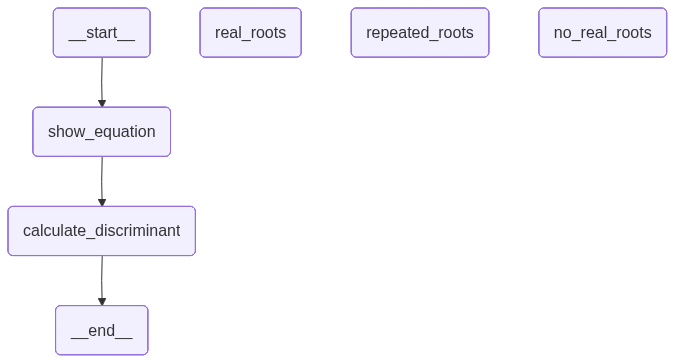

In [6]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

## Step 6 — Execute

Case 1: D > 0 → two real roots

In [7]:
state1 = {'a': 4, 'b': -5, 'c': -4, 'equation': None, 'discriminant': None, 'result': None}
out1 = workflow.invoke(state1)
print('Equation     :', out1['equation'])
print('Discriminant :', out1['discriminant'])
print('Result       :', out1['result'])

Equation     : 4x² - 5x - 4 = 0
Discriminant : 89
Result       : Two real roots: x1 = 1.8042, x2 = -0.5542


Case 2: D = 0 → one repeated root

In [8]:
state2 = {'a': 4, 'b': 4, 'c': 1, 'equation': None, 'discriminant': None, 'result': None}
out2 = workflow.invoke(state2)
print('Equation     :', out2['equation'])
print('Discriminant :', out2['discriminant'])
print('Result       :', out2['result'])

Equation     : 4x² + 4x + 1 = 0
Discriminant : 0
Result       : One repeated root: x = -0.5


Case 3: D < 0 → no real roots

In [9]:
state3 = {'a': 2, 'b': 4, 'c': 4, 'equation': None, 'discriminant': None, 'result': None}
out3 = workflow.invoke(state3)
print('Equation     :', out3['equation'])
print('Discriminant :', out3['discriminant'])
print('Result       :', out3['result'])

Equation     : 2x² + 4x + 4 = 0
Discriminant : -16
Result       : No real roots (discriminant < 0)
